In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/titanic_cleaned.csv")
print(df.shape)  # should show (782, ...)

(782, 18)


In [2]:
overall_survival = df["survived"].mean()
survival_by_class = df.groupby("pclass")["survived"].mean()
survival_by_sex = df.groupby("sex")["survived"].mean()
third_class_men = df[(df["pclass"] == 3) & (df["sex"] == "male")]["survived"].mean()

print(f"Overall: {overall_survival:.1%}")
print(survival_by_class)
print(survival_by_sex)
print(f"3rd class men: {third_class_men:.1%}")

Overall: 41.0%
pclass
1    0.627358
2    0.509091
3    0.256790
Name: survived, dtype: float64
sex
female    0.738832
male      0.215886
Name: survived, dtype: float64
3rd class men: 15.8%


# Executive Insight — Titanic Survival Analysis

## The One Thing to Know
**Survival wasn't random — it was determined by class and sex, and third-class 
men paid the highest price: only 15.8% survived.**

---

## Key Metrics

| Metric | Value | Benchmark | So What |
|---|---|---|---|
| Overall survival rate | 41.0% | — (baseline) | Less than half of all passengers survived — sets the context for every other number below |
| Survival by class (1st / 2nd / 3rd) | 62.7% / 50.9% / 25.7% | vs. 41.0% overall | 1st class survived 1.5x the overall rate; 3rd class survived at only 63% of it — class access was a major factor |
| Survival by sex (women / men) | 73.9% / 21.6% | vs. 41.0% overall | Women survived at nearly 2x the overall rate; men at roughly half — the single largest gap of any factor measured |
| **3rd-class men (worst-case group)** | **15.8%** | vs. 41.0% overall | **The largest passenger group on the ship (277 people) had the lowest survival odds of any segment — under 1 in 6 survived** |

---

## The Most Important Movement
**3rd-class men survived at 15.8% — less than 40% of the overall survival rate, 
and the worst outcome of any group on the ship.** This isn't a footnote; it's 
the headline risk this analysis surfaces.

---

## Recommended Action
**Mandate that lifeboat access and evacuation procedures be proportional across 
all cabin classes, not concentrated near upper-deck cabins**, in any future 
maritime safety policy this analysis informs.

**Expected impact:** If access were equalized so 3rd-class passengers survived 
at even the 2nd-class rate (50.9% vs. their actual 25.7%), an estimated 70+ 
additional passengers in this dataset alone would have survived — reflecting 
the scale of preventable loss driven by unequal access rather than chance.

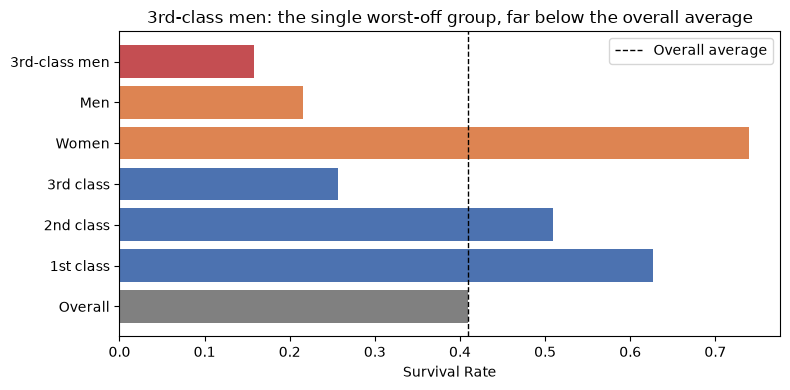

In [3]:
plt.figure(figsize=(8, 4))
groups = ["Overall", "1st class", "2nd class", "3rd class", "Women", "Men", "3rd-class men"]
values = [0.410, 0.627, 0.509, 0.257, 0.739, 0.216, 0.158]
colors = ["gray", "#4C72B0", "#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#C44E52"]

plt.barh(groups, values, color=colors)
plt.xlabel("Survival Rate")
plt.title("3rd-class men: the single worst-off group, far below the overall average")
plt.axvline(0.410, color="black", linestyle="--", linewidth=1, label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()